# Dynamic logit benchmark

Discrete-time hazard (pooled logit) default model, in the tradition of Shumway (2001) and Campbell, Hilscher & Szilagyi (2008). Estimated on pre-2006 firm-years and evaluated out of time on three forward windows (2006–2010, 2011–2015, post-2015).

**Notes for validation**
- **Inference:** standard errors are clustered by firm (`gvkey`), since the same firm appears in multiple years.
- **Goodness of fit:** out-of-sample pseudo-\(R^2\) is computed against a *forecast null* anchored to the training base rate (no future information in the null).
- Input: `intermediate/panel_clean.csv` (from `clean_data.ipynb`). Figures are written to `figures/`; prediction and summary CSVs (consumed by `comparison.ipynb`) to `intermediate/`.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import ks_2samp
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

## Configuration

`DATA_DIR` must point to the folder holding `intermediate/panel_clean.csv` (keep it consistent with `clean_data.ipynb`). Figures go to a repo-relative `figures/` folder so they can be committed.

In [2]:
# DATA_DIR must contain intermediate/panel_clean.csv (written by clean_data.ipynb).
# Default assumes the repo layout (notebooks/ and data/ are siblings). Override with:
#     export DATA_DIR=/absolute/path/to/your/Credit_risk/Data
DATA_DIR = Path(os.environ.get("DATA_DIR", "../data"))
INTERIM = DATA_DIR / "intermediate"
 
# figures/ lives at the repo root, one level up from notebooks/
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
 
# Fail early if the panel is missing. Raising rather than printing keeps local
# absolute paths out of committed notebook output.
if not (INTERIM / "panel_clean.csv").exists():
    raise FileNotFoundError(
        "panel_clean.csv not found under DATA_DIR/intermediate. Run clean_data.ipynb "
        "first, or set DATA_DIR, e.g. export DATA_DIR=/path/to/Data"
    )


## 1. Load panel and define the out-of-time splits

Train on fiscal years through 2005; test on 2006–2010, 2011–2015, and post-2015.

In [3]:
df = pd.read_csv(INTERIM / "panel_clean.csv")
 
features = [
    "leverage", "int_coverage", "roa", "current_ratio", "cash_ratio", "log_at",
    "nimta", "tlmta", "cashmta", "price", "trail_12m_ret", "eq_vol", "mtb",
]
outcome = "default_flag"
 
# Clean display names for figures
FEATURE_LABELS = {
    "leverage": "Book leverage", "int_coverage": "Interest coverage", "roa": "ROA",
    "current_ratio": "Current ratio", "cash_ratio": "Cash/assets", "log_at": "Log assets",
    "nimta": "NIMTA", "tlmta": "TLMTA", "cashmta": "CASHMTA", "price": "Log price",
    "trail_12m_ret": "Trailing 12-month return", "eq_vol": "Equity volatility", "mtb": "Market-to-book",
}
 
train = df[df["fyear"] <= 2005]
test_sets = {
    "test1": df[df["fyear"].between(2006, 2010)],
    "test2": df[df["fyear"].between(2011, 2015)],
    "test3": df[df["fyear"] > 2015],
}
 
# Sanity check: event counts and rates by period
for label, data in {"train": train, **test_sets}.items():
    n, tot = int(data[outcome].sum()), len(data)
    print(f"{label}: {n} defaults / {tot:,} firm-years ({n / tot * 100:.3f}%)")

train: 1448 defaults / 103,154 firm-years (1.404%)
test1: 197 defaults / 17,298 firm-years (1.139%)
test2: 121 defaults / 15,475 firm-years (0.782%)
test3: 104 defaults / 21,629 firm-years (0.481%)


## 2. Fit the dynamic logit

Pooled maximum likelihood on the training firm-years, with standard errors clustered by firm.

In [4]:
X_train = sm.add_constant(train[features])
y_train = train[outcome]

model = sm.Logit(y_train, X_train)
result = model.fit(cov_type="cluster", cov_kwds={"groups": train["gvkey"]})

# Average firm-years per firm (reported in the coefficient table; context for clustered inference)
avg_obs = train.groupby("gvkey").size().mean()
print(f"Average firm-years per firm: {avg_obs:.2f}\n")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.055344
         Iterations 10
Average firm-years per firm: 7.78

                           Logit Regression Results                           
Dep. Variable:           default_flag   No. Observations:               103154
Model:                          Logit   Df Residuals:                   103140
Method:                           MLE   Df Model:                           13
Date:                Wed, 12 Aug 2026   Pseudo R-squ.:                  0.2503
Time:                        20:58:31   Log-Likelihood:                -5709.0
converged:                       True   LL-Null:                       -7615.0
Covariance Type:              cluster   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -3.5455      0.163    -21.727      0.000      -3.

## 3. Out-of-sample discrimination

AUC-ROC (overall ranking), AUC-PR (precision-recall, the informative metric for rare events), and the KS statistic.

In [5]:
def evaluate(result, test_df, label):
    X = sm.add_constant(test_df[features])
    y = test_df[outcome]
    pred = result.predict(X)  # statsmodels returns probabilities
    ks, _ = ks_2samp(pred[y == 1], pred[y == 0])
    return {
        "label": label,
        "auc_roc": roc_auc_score(y, pred),
        "auc_pr": average_precision_score(y, pred),
        "ks": ks,
    }


pd.DataFrame([evaluate(result, d, lbl) for lbl, d in test_sets.items()]).set_index("label").round(4)

,auc_roc,auc_pr,ks
label,,,
test1,0.9243,0.2019,0.7102
test2,0.9017,0.0973,0.6976
test3,0.9057,0.0353,0.7195


### ROC curves and saved predictions

Saves per-firm predictions (with `fyear` and EAD) for the cross-model comparison, and the ROC figure.

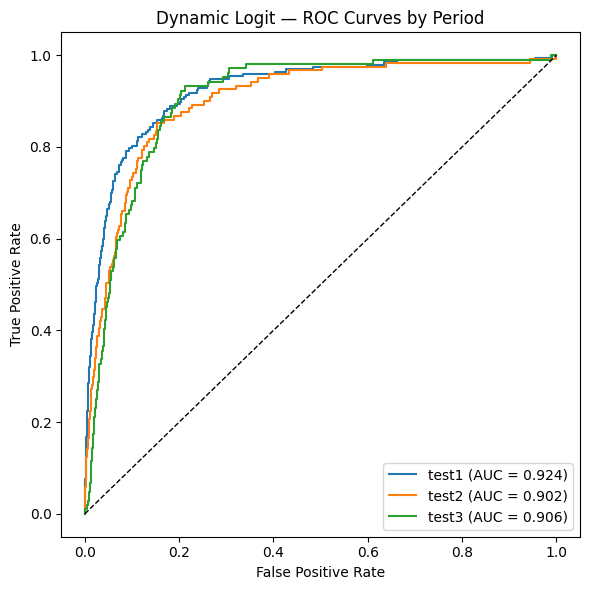

Saved 54,402 predictions to intermediate/logit_predictions.csv


In [6]:
pred_rows = []
plt.figure(figsize=(6, 6))
for label, test_df in test_sets.items():
    X = sm.add_constant(test_df[features])
    y = test_df[outcome]
    pred = result.predict(X)
 
    pred_rows.append(pd.DataFrame({
        "period": label,
        "fyear": test_df["fyear"].values,
        "y_true": y.values,
        "pred_proba": pred.values,
        "EAD": (test_df["dltt"] + test_df["dlc"]).values,
    }))
 
    fpr, tpr, _ = roc_curve(y, pred)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y, pred):.3f})")
 
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Dynamic Logit — ROC Curves by Period")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "logit_roc_curves.png", dpi=150)
plt.show()
 
logit_preds = pd.concat(pred_rows, ignore_index=True)
logit_preds.to_csv(INTERIM / "logit_predictions.csv", index=False)
print(f"Saved {len(logit_preds):,} predictions to intermediate/logit_predictions.csv")

## 4. Calibration

Average predicted PD versus realized default rate per window. Ratio > 1 = overprediction, < 1 = underprediction.

In [7]:
rows = []
for label, test_df in test_sets.items():
    pred_pd = result.predict(sm.add_constant(test_df[features]))
    rows.append({
        "period": label,
        "avg_predicted_PD": pred_pd.mean(),
        "actual_default_rate": test_df[outcome].mean(),
    })
cal = pd.DataFrame(rows).set_index("period")
cal["ratio"] = cal["avg_predicted_PD"] / cal["actual_default_rate"]
print(cal.round(4))

        avg_predicted_PD  actual_default_rate   ratio
period                                               
test1             0.0074               0.0114  0.6477
test2             0.0060               0.0078  0.7663
test3             0.0096               0.0048  1.9970


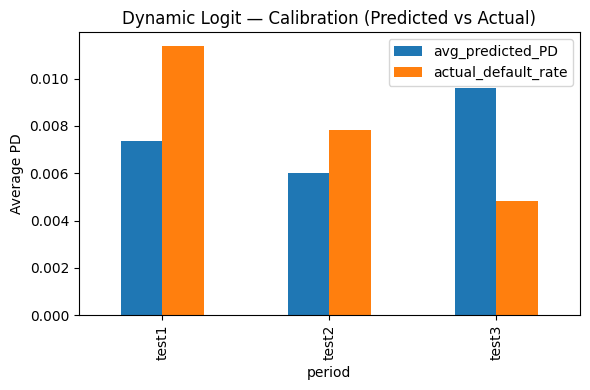

In [8]:
ax = cal.plot(kind="bar", y=["avg_predicted_PD", "actual_default_rate"], figsize=(6, 4))
ax.set_ylabel("Average PD")
ax.set_title("Dynamic Logit — Calibration (Predicted vs Actual)")
plt.tight_layout()
plt.savefig(FIG_DIR / "logit_calibration.png", dpi=150)
plt.show()

## 5. Goodness of fit — pseudo-\(R^2\)

In-sample McFadden pseudo-\(R^2\) from statsmodels, and out-of-sample pseudo-\(R^2\) against a forecast null that predicts the **training** base rate for every test observation (only information available at prediction time).

In [9]:
def pseudo_r2_oos(result, test_df, train_base_rate):
    """McFadden pseudo-R^2 on a test set, null = training base rate (a true forecast null)."""
    X = sm.add_constant(test_df[features])
    y = test_df[outcome].values
    pred = np.clip(result.predict(X).values, 1e-10, 1 - 1e-10)
    llf = np.sum(y * np.log(pred) + (1 - y) * np.log(1 - pred))
    p0 = train_base_rate
    ll0 = np.sum(y * np.log(p0) + (1 - y) * np.log(1 - p0))
    return 1 - llf / ll0
 
 
train_base_rate = train[outcome].mean()
print(f"In-sample pseudo-R^2:  {result.prsquared:.4f}")
print("Campbell (2008) ref.:  0.3120\n")
 
oos = pd.DataFrame(
    [{"period": lbl, "pseudo_r2": pseudo_r2_oos(result, d, train_base_rate)} for lbl, d in test_sets.items()]
).set_index("period")
print("Out-of-sample pseudo-R^2:")
print(oos.round(4))

In-sample pseudo-R^2:  0.2503
Campbell (2008) ref.:  0.3120

Out-of-sample pseudo-R^2:
        pseudo_r2
period           
test1      0.3030
test2      0.2519
test3      0.2030


### Save summary metrics

One row per window (plus an in-sample row) for the cross-model comparison table.

In [10]:
summary_rows = []
for label, test_df in test_sets.items():
    perf = evaluate(result, test_df, label)
    pred = result.predict(sm.add_constant(test_df[features]))
    summary_rows.append({
        "model": "logit", "period": label,
        "auc_roc": perf["auc_roc"], "auc_pr": perf["auc_pr"], "ks": perf["ks"],
        "pseudo_r2": pseudo_r2_oos(result, test_df, train_base_rate),
        "calibration_ratio": pred.mean() / test_df[outcome].mean(),
    })
summary_rows.append({
    "model": "logit", "period": "in_sample",
    "auc_roc": np.nan, "auc_pr": np.nan, "ks": np.nan,
    "pseudo_r2": result.prsquared, "calibration_ratio": np.nan,
})

logit_summary = pd.DataFrame(summary_rows)
logit_summary.to_csv(INTERIM / "logit_summary.csv", index=False)
logit_summary

,model,period,auc_roc,auc_pr,ks,pseudo_r2,calibration_ratio
0,logit,test1,0.924274,0.201891,0.710178,0.302971,0.647720
1,logit,test2,0.901745,0.097279,0.697599,0.251920,0.766289
2,logit,test3,0.905656,0.035319,0.719452,0.202953,1.996973
3,logit,in_sample,NaN,NaN,NaN,0.250296,NaN


## 6. Expected loss

\(EL = PD \times EAD \times LGD\), with EAD proxied by total debt and LGD fixed at 45% (Basel Foundation IRB). Reported as annual averages within each window (aggregate by year, then average) so figures are a point-in-time portfolio, not a multi-year sum.

In [11]:
LGD = 0.45
for label, test_df in test_sets.items():
    t = test_df.copy()
    t["EAD"] = t["dltt"] + t["dlc"]
    t["PD"] = result.predict(sm.add_constant(t[features]))
    t["EL"] = t["PD"] * t["EAD"] * LGD
    annual = t.groupby("fyear")[["EAD", "EL"]].sum()
    avg_EAD, avg_EL = annual["EAD"].mean(), annual["EL"].mean()
    print(f"{label}  |  Avg Annual EAD: ${avg_EAD / 1e3:,.1f}B  |  "
          f"Avg Annual EL: ${avg_EL / 1e3:,.1f}B  |  EL/EAD: {avg_EL / avg_EAD * 100:.2f}%  |  "
          f"Avg PD: {t['PD'].mean() * 100:.2f}%")

test1  |  Avg Annual EAD: $4,065.5B  |  Avg Annual EL: $3.7B  |  EL/EAD: 0.09%  |  Avg PD: 0.74%
test2  |  Avg Annual EAD: $5,549.2B  |  Avg Annual EL: $4.4B  |  EL/EAD: 0.08%  |  Avg PD: 0.60%
test3  |  Avg Annual EAD: $8,659.4B  |  Avg Annual EL: $6.2B  |  EL/EAD: 0.07%  |  Avg PD: 0.96%


## 7. Average marginal effects

Logit coefficients on the probability scale: \(\text{AME}_k = \beta_k \cdot \mathbb{E}[P(1-P)]\). Standardized AMEs scale by each predictor's standard deviation (effect of a 1-SD change on PD).

In [12]:
def ame(result, data):
    P = result.predict(sm.add_constant(data[features]))
    scale = P * (1 - P)
    return pd.Series({f: (result.params[f] * scale).mean() for f in features})


ame_table = {lbl: ame(result, d) for lbl, d in {"train": train, **test_sets}.items()}
ame_std_df = pd.DataFrame(
    {lbl: ame_table[lbl] * d[features].std() for lbl, d in {"train": train, **test_sets}.items()}
).round(6)
ame_std_df

,train,test1,test2,test3
leverage,0.003369,0.001867,0.001544,0.002557
int_coverage,-0.001699,-0.001701,-0.001419,-0.002401
roa,-0.002361,-0.001236,-0.000916,-0.001902
current_ratio,-0.005548,-0.002765,-0.002421,-0.004214
cash_ratio,0.000615,0.000385,0.000305,0.000510
log_at,-0.008502,-0.004436,-0.003636,-0.005587
nimta,-0.000096,-0.000054,-0.000036,-0.000081
tlmta,0.006157,0.003228,0.002585,0.003940
cashmta,-0.002298,-0.001497,-0.001133,-0.002151
price,-0.006120,-0.003132,-0.002448,-0.003777


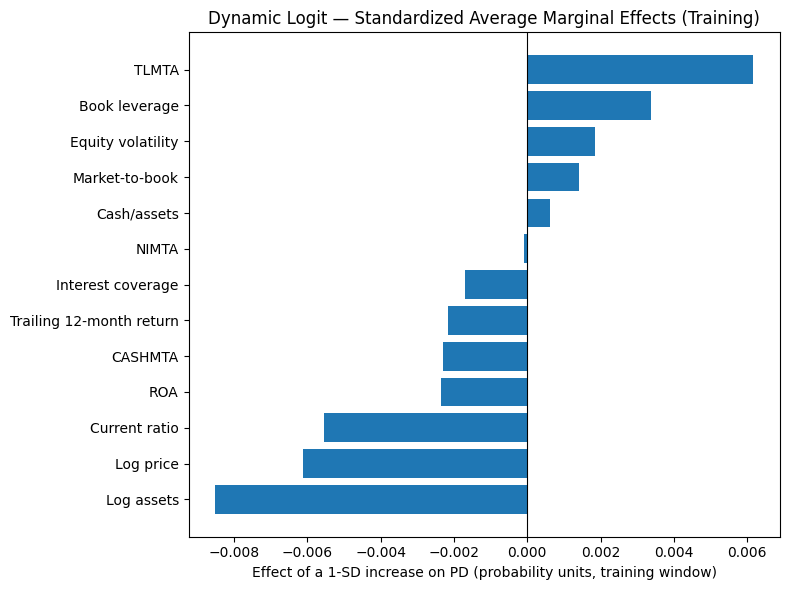

In [13]:
ame_std_sorted = ame_std_df["train"].sort_values()
labels = [FEATURE_LABELS.get(f, f) for f in ame_std_sorted.index]

plt.figure(figsize=(8, 6))
plt.barh(labels, ame_std_sorted.values)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Effect of a 1-SD increase on PD (probability units, training window)")
plt.title("Dynamic Logit — Standardized Average Marginal Effects (Training)")
plt.tight_layout()
plt.savefig(FIG_DIR / "logit_ame_std.png", dpi=150)
plt.show()

## 8. Confusion matrices at the KS-optimal threshold

Per window, the threshold that maximizes the KS separation between defaulters and non-defaulters.

In [14]:
def confusion_at_ks_threshold(result, test_df, label):
    X = sm.add_constant(test_df[features])
    y = test_df[outcome]
    pred = result.predict(X)
 
    thresholds = np.sort(pred.unique())
    ks_scores = [
        ((pred >= t) & (y == 1)).sum() / (y == 1).sum()
        - ((pred >= t) & (y == 0)).sum() / (y == 0).sum()
        for t in thresholds
    ]
    best_t = thresholds[int(np.argmax(ks_scores))]
    cm = confusion_matrix(y, (pred >= best_t).astype(int))
 
    print(f"\n-- {label}  (threshold = {best_t:.4f}) --")
    print("                 Predicted Safe  Predicted Default")
    print(f"Actual Safe      {cm[0, 0]:>14,}  {cm[0, 1]:>17,}")
    print(f"Actual Default   {cm[1, 0]:>14,}  {cm[1, 1]:>17,}")
    print(classification_report(y, (pred >= best_t).astype(int), target_names=["Safe", "Default"]))
 
 
for label, test_df in test_sets.items():
    confusion_at_ks_threshold(result, test_df, label)


-- test1  (threshold = 0.0120) --
                 Predicted Safe  Predicted Default
Actual Safe              15,183              1,918
Actual Default               35                162
              precision    recall  f1-score   support

        Safe       1.00      0.89      0.94     17101
     Default       0.08      0.82      0.14       197

    accuracy                           0.89     17298
   macro avg       0.54      0.86      0.54     17298
weighted avg       0.99      0.89      0.93     17298


-- test2  (threshold = 0.0068) --
                 Predicted Safe  Predicted Default
Actual Safe              12,995              2,359
Actual Default               18                103
              precision    recall  f1-score   support

        Safe       1.00      0.85      0.92     15354
     Default       0.04      0.85      0.08       121

    accuracy                           0.85     15475
   macro avg       0.52      0.85      0.50     15475
weighted avg       0.99  